<table>
 <tr align=left><td><img align=left src="https://i.creativecommons.org/l/by/4.0/88x31.png">
 <td>Text provided under a Creative Commons Attribution license, CC-BY. All code is made available under the FSF-approved MIT license. (c) Kyle T. Mandli</td>
</table>

Material heavily borrowed from David I. Ketcheson's [HyperPython](https://github.com/ketch/HyperPython) under a similar license as the one above.  Mistakes introduced are the responsibility of Kyle Mandli so complain to him.

If you are interested in the animation tools used there is a tutorial on their use at 

https://nbviewer.jupyter.org/url/www.clawpack.org/_static/notebooks/animation_tools_demo.ipynb

In [2]:
%matplotlib inline

from __future__ import print_function
import numpy
import matplotlib.pyplot as plt

# Note that this module is found in the base directory
import utils.animation as animation

# Finite Volume Methods

## **Hukum Konservasi Hiperbolik**

Sebelum kita secara khusus membahas metode volume hingga, kita akan menjelajahi kelas PDE yang disebut persamaan konservasi hiperbolik. Persamaan ini umumnya menggambarkan pergerakan suatu besaran fisik yang harus dilestarikan. Contoh besaran tersebut meliputi massa, momentum, atau energi.

### Konservasi Massa

Bayangkan sebuah fluida mengalir di dalam sebuah pipa sempit. Kita akan memakai $q$ untuk menyatakan kerapatan (density) fluida dan $u$ untuk menyatakan kecepatannya. Keduanya bergantung pada ruang dan waktu: $q = q(x,t)$; $u = u(x,t)$. Total massa pada segmen pipa $[x_1,x_2]$ adalah

\begin{equation}
\int_{x_1}^{x_2} q(x,t)\, dx.
\end{equation}

Total massa ini dapat berubah seiring waktu karena fluida yang masuk atau keluar dari segmen pipa tersebut. Kita menyebut laju aliran ini *fluks*, dan merepresentasikannya dengan fungsi $f(q)$. Dengan demikian, laju bersih aliran massa yang masuk (atau keluar) ke interval $[x_1,x_2]$ pada waktu $t$ adalah

$$f(q(x_1,t)) - f(q(x_2,t)).$$

Kita baru saja mengatakan bahwa laju aliran ini harus sama dengan laju perubahan waktu dari massa total; yaitu
$$
    \frac{d}{dt} \int_{x_1}^{x_2} q(x,t) dx = f(q(x_1,t)) - f(q(x_2,t)).
$$

Dengan mengasumsikan bahwa fungsi-fungsi tersebut cukup kontinu, kita dapat menulis
$$
    \int_{x_1}^{x_2} \frac{\partial}{\partial x} f(q) dx = f(q(x_2,t)) - f(q(x_1,t))
$$ 
oleh karena itu kita dapat menuliskan kembali hukum konservasi kita sebagai
$$
    \frac{d}{dt} \int_{x_1}^{x_2} q(x,t) dx = -\int_{x_1}^{x_2} \frac{\partial}{\partial x} f(q) dx.
$$

Di bawah asumsi kelancaran tertentu pada $q$, kita dapat memindahkan turunan terhadap waktu ke dalam integral. Kita juga akan memindahkan semuanya ke ruas kiri, sehingga diperoleh
$$
    \int_{x_1}^{x_2} \left(\frac{\partial}{\partial t}q(x,t) + \frac{\partial}{\partial x} f(q)\right) dx = 0.
$$

Karena integral ini bernilai nol untuk *setiap* pilihan $x_1,x_2$, haruslah integrand (ekspresi dalam tanda kurung) sebenarnya bernilai nol *di mana-mana*! Oleh karena itu kita dapat menuliskan **hukum konservasi dalam bentuk diferensial**
$$
    q(x,t)_t + f(q(x,t))_x = 0.
$$

Persamaan ini menyatakan bahwa massa total terkonservasi — secara lokal massa hanya dapat berubah akibat aliran bersih masuk atau keluar.

### Adveksi

Untuk menyelesaikan hukum konservasi di atas, kita memerlukan ekspresi untuk fluks, $f$. Laju aliran hanyalah massa dikalikan dengan kecepatan: $f = u q$. Dengan demikian kita memperoleh **persamaan kontinuitas**

$$
    q_t + (u q)_x = 0.
$$

Secara umum, kita memerlukan persamaan lain untuk menentukan kecepatan \(u(x,t)\). Nanti kita akan melihat persamaan penuh dinamika fluida, tetapi untuk sekarang mari kita pertimbangkan kasus paling sederhana, di mana seluruh fluida bergerak dengan kecepatan konstan tunggal \(u(x,t)=a\). Maka persamaan kontinuitas menjadi persamaan adveksi

$$q_t + a q_x = 0.$$

Kita sudah melihat bahwa solusi persamaan adveksi adalah $\;q(x,t) = q_0(x-at).\;$ Mari kita plot solusi persamaan adveksi pada interval $[0,1]$ untuk kondisi awal $q_0(x) = e^{-2(x-1/2)^2}.$

In [3]:
# Grid
x = numpy.linspace(0, 1, 1000) 

# Advection speed
a = 1.0                    

# Initial condition
def q_0(x): 
    return numpy.exp(-200.*(x-0.2)**2)

figs = []
for t in numpy.linspace(0,1):
    figs.append(plt.figure(figsize=(8, 4)))
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, q_0(x - a * t), linewidth=2)
    axes.set_xlim((0, 1))
    axes.set_ylim((-0.1, 1.1))
    axes.set_xlabel("$x$")
    axes.set_ylabel("$q(x,t)$")
    axes.set_title("Solution to the advection equation")
    plt.close(figs[-1])
    
# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

Seperti yang terlihat, pulsa awal hanya bergerak ke kanan dengan kecepatan $a$ seiring berjalannya waktu. Ini tidak terlalu menarik, tetapi menangkap fitur terpenting dari persamaan hiperbolik: gelombang merambat dengan kecepatan terbatas.  
### Metode Volume Hingga untuk Adveksi

Kita dapat dengan mudah menyelesaikan persamaan adveksi secara eksak. Namun persamaan adveksi merupakan prototipe untuk hukum konservasi yang lebih rumit yang hanya dapat kita selesaikan secara pendekatan menggunakan metode numerik. Untuk memahami metode-metode ini lebih baik, kita akan membahasnya terlebih dahulu dalam konteks persamaan adveksi.  
Untuk kesederhanaan, anggap kita ingin menyelesaikan persamaan adveksi pada interval $[0,1]$. Kita memperkenalkan sekumpulan *sel grid* berjarak sama dengan lebar $\Delta x$, dan menulis $x_i$ untuk menyatakan pusat sel ke-$i$. Dengan demikian sel pertama adalah interval $[0,\Delta x]$ dan $x_1=\Delta x/2$. Kita juga akan menulis $x_{i-1/2}$ atau $x_{i+1/2}$ untuk menyatakan batas kiri atau kanan sel $i$, berturut‑turut.

Kita tulis $Q_i$ untuk menyatakan nilai *rata‑rata* solusi pada sel $i$:

$$
Q_i = \frac{1}{\Delta x}\int_{x_{i-1/2}}^{x_{i+1/2}} q \, dx.
$$

Metode volume hingga paling sederhana diperoleh dengan menganggap bahwa solusi benar‑benar sama dengan $Q_i$ di seluruh sel $i$.

![](./images/finite_volume.png)

Misalkan $a>0$. Maka fluks masuk ke sel $i$ dari kiri adalah $a Q_{i-1}$ dan fluks keluar dari sel $i$ ke kanan adalah $a Q_i$. Dengan demikian hukum konservasi integral kita menjadi

$$Q_i'(t) = -\frac{a}{\Delta x}\left(Q_i - Q_{i-1}\right).$$

Dengan menerapkan beda maju pada waktu kita memperoleh metode upwind

$$
    Q^{n+1}_i = Q^n_i -\frac{a \Delta t}{\Delta x}\left(Q_i - Q_{i-1}\right).
$$

Ini tentu juga merupakan metode upwind yang sama dengan yang kita turunkan ketika membahas beda hingga.

In [4]:
a = 1.0

m = 100
delta_x = 1.0 / float(m)
x = numpy.arange(-delta_x / 2.0, 1.0 + delta_x / 2.0, delta_x)

t = 0.0
T = 0.5
CFL = 0.8
delta_t = CFL * delta_x / a

# Initial data
def q_0(x):
    return numpy.exp(-200.*(x-0.2)**2)
Q = q_0(x)
Q_new = Q.copy()

figs = []
while t < T:
    # Incoming wave
#     Q_new[0] = numpy.sin(20.0 * numpy.pi * t)
    # Extrapolation BCs
    Q_new[0] = Q_new[1]
    
    Q_new[1:] = Q[1:] - a * delta_t / delta_x * (Q[1:] - Q[:-1])
    
    Q = Q_new.copy()
    t = t + delta_t
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, q_0(x - a * t), 'k', linewidth=2, label="True Solution")
    axes.plot(x, Q, 'o-', linewidth=2, label="Upwind")
    axes.set_title('t = %s' % str(t))
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim((-1.1, 1.1))
    axes.set_xlabel("$x$")
    axes.set_ylabel("$q(x,t)$")
    axes.set_title("Upwind Method")
    axes.legend(loc=4)
    plt.close(figs[-1])

# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

plt.show()

Kita dapat melihat bahwa kita memilih $\Delta t$ berdasarkan kondisi CFL yang kita turunkan untuk metode beda hingga. Hal yang sama berlaku di sini (kita bahkan menggunakan metode yang sama).  
Perhatikan bagaimana kita menyusun grid yang berisi sebuah sel tambahan di tiap ujung, di luar domain masalah $[0,1]$. Sel‑sel ini disebut *sel hantu* dan sering berguna untuk menangani solusi pada batas grid.

![](./images/ghost-cell.png)

Teknik yang kita gunakan di atas untuk menetapkan nilai sel hantu, dengan menyalin nilai terakhir di dalam grid ke sel hantu, dikenal sebagai *ekstrapolasi orde nol*. Teknik ini berguna untuk memungkinkan gelombang keluar dari domain (batas yang *tanpa pantulan*). Perhatikan bahwa kita sebenarnya tidak memerlukan sel hantu di ujung kanan untuk metode upwind, tetapi untuk metode lain kita membutuhkannya.

Metode upwind sederhana, tetapi tidak terlalu akurat. Amati bagaimana solusi yang dihitung menjadi lebih lebar dan lebih pendek seiring waktu. Perilaku ini disebut *dissipasi*.

## Derivasi Alternatif

Cara lain memandang metode volume hingga adalah lebih langsung sebagai diskretisasi PDE:
$$
    \frac{d}{dt} \int_{x_1}^{x_2} q(x,t) dx = f(q(x_1,t)) - f(q(x_2,t)).
$$

menjadi

$$
    Q_i^{n+1} = Q^n_i - \frac{\Delta t}{\Delta x} \left[ F^n_{i+1/2} - F^n_{i-1/2} \right]
$$

![Stencil](./images/flux_stencil.png)

![Averaging view of advection](./images/ave_demo.png)

Jika fluks dari kiri sel $i$ menyatakan bahwa nilai $Q^n_{i-1}$ masuk dengan kecepatan $\lambda$ maka nilai itu akan menempati panjang $\lambda \Delta t$ dari total panjang sel $i$, menyisakan $\Delta x - \lambda \Delta t$ dengan nilai asli $Q^n_i$. Merata‑ratarakan kedua nilai ini untuk memperoleh $Q^{n+1}_i$ menghasilkan

$$\begin{aligned}
    Q^{n+1}_i &= \frac{Q^n_i (\Delta x - \lambda \Delta t) + Q^n_{i-1} \lambda \Delta t}{\Delta x} \\
    &=Q^n_i - \frac{\lambda \Delta t}{\Delta x} [Q^n_i - Q^n_{i-1}],
\end{aligned}$$

tepat metode upwind!
## Aliran Lalu Lintas

Sebagai contoh ilustratif kita akan mempertimbangkan suatu hukum konservasi skalar tertentu, yaitu model sederhana untuk aliran lalu lintas. Model ini kadang disebut model Lighthill–Whitham–Richards (LWR).
Dari persamaan kontinuitas di atas kita punya:

$$q_t + (uq)_x = 0.$$

Sekarang kita anggap $q$ sebagai kepadatan mobil di jalan, yang bergerak dengan kecepatan $u$. Perhatikan bahwa kita tidak melacak mobil satu per satu, melainkan hanya jumlah rata‑rata mobil per satuan panjang jalan. Jadi $q=0$ berarti jalan kosong, dan kita bisa memilih satuan sehingga $q=1$ berarti jalan penuh rapat (bumper-to-bumper).
Kita juga pilih satuan sehingga batas kecepatan adalah $u_\text{max}=1$, dan mengasumsikan pengemudi tidak pernah melebihi ini. Jika kita mengasumsikan pengemudi selalu bergerak dengan kecepatan seragam, kita kembali mendapatkan persamaan adveksi. Namun pada kenyataannya mobil melaju lebih cepat saat lalu lintas lengang dan lebih lambat saat padat. Cara paling sederhana untuk memasukkan efek ini adalah membuat kecepatan menurun secara linier terhadap kepadatan:

$$u(q) = 1 - q.$$
Perhatikan bahwa $u$ menjadi nol saat $q$ mendekati kepadatan maksimum 1, sedangkan $u$ menjadi maksimum 1 saat kepadatan mendekati nol. Jelas, baik $q$ maupun $u$ seharusnya selalu berada dalam interval $[0,1]$.

![](./images/LWR-Velocity.png)

Menggabungkan kedua persamaan di atas, hukum konservasi kita menjadi

$$q_t + (q (1-q))_x = 0.$$

Fungsi $q(1-q)$ adalah fluks, atau laju aliran mobil. Perhatikan bahwa fluks bernilai nol saat tidak ada mobil dan juga saat jalan penuh total. Aliran maksimum sebenarnya terjadi ketika jalan setengah penuh:

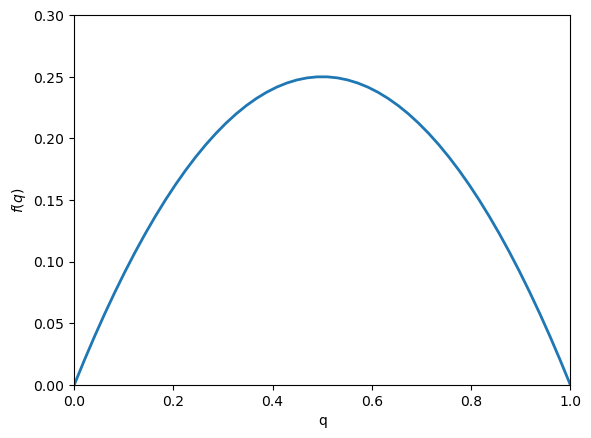

In [12]:
q = numpy.linspace(0, 1)
f = q * (1.0 - q)
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(q,f,linewidth=2)
axes.set_xlabel('q')
axes.set_ylabel('$f(q)$')
axes.set_xlim((0, 1))
axes.set_ylim((0.0, 0.3))
plt.show()

Persamaan ini secara mendasar berbeda dari persamaan adveksi karena fluksnya bersifat **nonlinear**. Keadaan ini akan memberikan konsekuensi yang dramatis baik pada perilaku solusi maupun pada metode numerik kita. Namun secara superfisial kita dapat membuat persamaan ini tampak seperti persamaan adveksi dengan menggunakan aturan rantai:

$$f(q)_x = f'(q)\, q_x = (1-2q)q_x.$$

Maka kita memperoleh

$$q_t + (1-2q)q_x = 0.$$

Ini mirip dengan persamaan adveksi, tetapi dengan kecepatan $1-2q$ yang bergantung pada kepadatan mobil. Nilai $f'(q)=1-2q$ disebut sebagai *kecepatan karakteristik*. Kecepatan karakteristik ini bukanlah kecepatan gerak mobil (perhatikan bahwa nilainya bahkan bisa negatif!). Sebaliknya, ini adalah kecepatan di mana *informasi* ditransmisikan sepanjang jalan.
### Gelombang kejut (kemacetan lalu lintas)

Mari kita gunakan metode *Lax–Friedrichs* untuk menyelesaikan model lalu lintas LWR.

In [8]:
m = 100
delta_x = 1.0 / m
x = numpy.arange(-delta_x / 2.0, 1.0 + delta_x / 2.0, delta_x)

t = 0.0
T = 0.5
CFL = 0.9
delta_t = CFL * delta_x

Q = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new = numpy.empty(Q.shape)
Q_list = [Q]

figs = []
while t < T:
    
    Q_new[1:-1] = 0.5 * (Q[:-2] + Q[2:]) - 0.5 * delta_t / delta_x \
                                               * (Q[2:] * (1.0 - Q[2:]) - Q[:-2] * (1.0 - Q[:-2]))
    
    Q = Q_new.copy()
    Q[0] = Q[-2]
    Q[-1] = Q[1]
    t += delta_t
    
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, Q, 'o-', linewidth=2)
    axes.set_title('Lax-Friedrichs Method - Traffic Flow at t = %s' % str(t))
    axes.set_xlabel("$x$")
    axes.set_ylabel("$q(x,t)$")
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim((-0.1, 1.1))
    plt.close(figs[-1])
    plt.show()

# Animate the solution
images = animation.make_images(figs)


Dimulai dari distribusi mobil yang awalnya halus, kita melihat bahwa solusi berkembang menjadi sesuatu yang tidak kontinu! Apa yang terjadi?  
Secara alami, mobil‑mobil di daerah kepadatan rendah di belakang puncak awalnya bergerak lebih cepat dibandingkan mobil‑mobil di daerah paling padat di depannya. Hal ini menyebabkan bagian belakang arus lalu lintas menjadi semakin curam, dan akhirnya terjadi kemacetan: mobil‑mobil yang datang dari belakang memiliki jalan yang kosong, hingga tiba‑tiba mereka mencapai daerah yang sangat padat dan harus mengerem mendadak. Kedengarannya familiar?

### Kecepatan gelombang kejut: kondisi Rankine–Hugoniot

Pada latihan kedua di atas, Anda seharusnya telah melihat gelombang kejut (yaitu, sebuah diskontinuitas) yang bergerak ke kiri saat semakin banyak mobil menumpuk di belakang lampu merah. Seberapa cepat diskontinuitas ini bergerak ke kiri?

Kita dapat mengetahuinya dengan menempatkan sebuah garis khayal pada lokasi kejut. Misalkan $q_l$ adalah kepadatan mobil tepat di kiri garis, dan $q_r$ adalah kepadatan mobil tepat di kanan garis. Bayangkan sejenak garis tersebut diam. Maka laju mobil yang mencapai garis dari kiri adalah $f(q_l)$ dan laju mobil yang meninggalkan garis ke kanan adalah $f(q_r)$. Jika garis itu benar‑benar diam, kita perlu memiliki $f(q_l)-f(q_r)=0$ agar tidak terjadi penumpukan mobil pada garis tersebut.

![](./images/shock_diagram_traffic_a.png)

Namun, kejut tersebut tidak diam, sehingga garis itu bergerak. Misalkan $s$ adalah kecepatan kejut. Ketika garis bergerak ke kiri, beberapa mobil yang sebelumnya di kiri sekarang berada di kanan garis. Laju mobil yang hilang dari kiri adalah $s q_l$ dan laju mobil yang bertambah di kanan adalah $s q_r$. Jadi untuk menghindari penumpukan mobil pada kejut, kedua pengaruh ini harus seimbang:
$$
    f(q_l) - f(q_r) = s(q_l - q_r).
$$

Kondisi ini dikenal sebagai *kondisi Rankine–Hugoniot*, dan berlaku untuk setiap gelombang kejut dalam solusi dari sistem hiperbolik manapun.

![](./images/shock_diagram_traffic_b.png)

Cara lain yang lebih analitik untuk mendapatkan kondisi Rankine–Hugoniot adalah dengan mempertimbangkan sebuah persegi panjang $[x_1, x_1 + \Delta x] \times [t_1, t_1 + \Delta t]$ yang dibagi oleh sebuah kejut dengan kecepatan $s$.

Dengan menerapkan hukum konservasi integral pada daerah ini dengan mengasumsikan bahwa $q$ konstan di setiap wilayah kita memiliki
$$\begin{aligned}
    \int^{x_1 + \Delta x}_{x_1} q(x, t_1 + \Delta t) dx - \int^{x_1 + \Delta x}_{x_1} q(x, t_1) dx &= \int^{t_1 + \Delta t}_{t_1} q(x_1, t) dt - \int^{t_1 + \Delta t}_{t_1} q(x_1 + \Delta x, t) dt \\
    \Delta x q_r - \Delta x q_\ell &= \Delta t f(q_\ell) - \Delta t f(q_r) + \mathcal{O}(\Delta t^2) \\
    \frac{\Delta x}{\Delta t} (q_r - q_\ell) &=  (f(q_\ell) -  f(q_r)) + \mathcal{O}(\Delta t)
\end{aligned}$$

lalu dengan mengambil $\Delta t \rightarrow 0$ kita peroleh
$$
    s (q_r - q_\ell) =  f(q_r) -  f(q_\ell)
$$

dengan memperhatikan bahwa $-s \Delta t = \Delta x$.

### Gelombang Rarefaksi

Mengapa kita tidak melihat gelombang kejut pada latihan ketiga di atas? Pada awalnya solusi bersifat diskontinu, tetapi setelah waktu nol solusi menjadi kontinu.

Secara fisika, alasannya jelas: setelah lampu berubah menjadi hijau, mobil‑mobil di depan mempercepat dan menyebar; kemudian mobil‑mobil di belakangnya ikut mempercepat, dan seterusnya. Jenis gelombang perluasan semacam ini disebut *gelombang rarefaksi* dengan analogi pada dinamika fluida.

Bagaimana kita menentukan apakah diskontinuitas awal akan menghasilkan kejut atau rarefaksi?
- Kejut muncul di daerah di mana karakteristik saling bertumpuk:

![](./images/entropy_condition_shock.png)
- Rarefaksi muncul di daerah di mana karakteristik saling menjauhi:

![](./images/entropy_condition_rarefaction.png)

Lebih tepatnya, jika nilai di kiri kejut adalah \(q_\ell\) dan nilai di kanan adalah \(q_r\), maka harus berlaku \(f'(q_\ell) > f'(q_r)\). Bahkan kecepatan kejut harus terletak di antara kecepatan karakteristik ini:

$$f'(q_\ell) > s > f'(q_r).$$

Kita mengatakan bahwa karakteristik *menabrak* (impinge on) kejut. Hal ini dikenal sebagai *kondisi entropi*, karena pada dinamika fluida kejut semacam ini mematuhi hukum kedua termodinamika.

Sebaliknya, jika \(f'(q_\ell) < f'(q_r)\), maka yang muncul adalah gelombang rarefaksi.

### Masalah Riemann

Masalah yang Anda setup pada latihan lampu merah dan hijau di atas adalah contoh dari apa yang disebut masalah Riemann. Sebuah masalah Riemann terdiri dari sebuah hukum konservasi hiperbolik, beserta data awal yang potong‑berpotong konstan dengan satu titik diskontinuitas:

$$q(x,0) = \begin{cases} q_\ell & x < x_0 \\ q_r & x > x_0 \end{cases}$$

Sebenarnya, seluruh metode volume hingga kita dibangun di atas penyelesaian aproksimasi masalah Riemann. Karena solusi didekati oleh fungsi konstan pada tiap sel, sebuah masalah Riemann muncul pada setiap antarmuka antara dua sel. Metode upwind untuk adveksi didasarkan pada penyelesaian eksak masalah Riemann untuk mendapatkan fluks (tentu saja, masalah Riemann untuk adveksi sangat sederhana untuk diselesaikan). Fluks Lax‑Friedrichs didasarkan pada pendekatan solusi masalah Riemann.

Untuk sistem PDE hiperbolik nonlinier, seperti persamaan Euler yang akan kita bahas nanti, solusi masalah Riemann bisa sangat rumit. Metode komputasi untuk menyelesaikan sistem semacam itu biasanya didasarkan pada penyelesai Riemann aproksimasi. Kita tidak akan masuk ke teori masalah Riemann atau penyelesai Riemann aproksimasi dalam mata kuliah ini.

## Metode Resolusi Tinggi

Metode‑metode yang telah kita gunakan sejauh ini (metode upwind dan metode Lax‑Friedrichs) bersifat disipatif. Artinya, seiring waktu mereka secara artifisial menyebarkan (smear) solusi — terutama kejut. Selain itu, kedua metode ini hanya *orde satu* akuratnya, yang berarti bila kita mengurangi \(\Delta t\) dan \(\Delta x\) sebesar faktor dua, galat keseluruhan hanya berkurang sekitar faktor dua. Kita bisa melakukan lebih baik.

### Mengurangi Difusi (Disipasi)

Langkah pertama untuk meningkatkan akurasi adalah menggunakan representasi \(q(x)\) yang lebih akurat pada tiap langkah. Alih‑alih mengasumsikan \(q\) potong‑berpotong konstan, sekarang kita aproksimasi dengan fungsi potong‑berpotong linear:

$$q(x) = Q^n_i + \sigma^n_i (x-x_i).$$

Di sini \(\sigma_i\) merepresentasikan kemiringan (slope) di sel \(i\). Pilihan paling jelas untuk memastikan aproksimasi orde dua adalah menggunakan aproksimasi tersentral

$$\sigma^n_i = \frac{Q^n_{i+1} - Q^n_{i-1}}{2\Delta x}.$$

Kita gunakan ini untuk memperoleh nilai pada antarmuka sel:

$$\begin{aligned}
q^+_{i - 1/2} & = Q_i - \sigma_i \frac{\Delta x}{2} \\
q^-_{i + 1/2} & = Q_i + \sigma_i \frac{\Delta x}{2}.
\end{aligned}$$

![](./images/linear_reconstruction.png)

Kita akan menggunakan nilai antarmuka ini untuk mengaproksimasi fluks, berdasarkan *fluks Lax–Friedrichs* (terkait dengan metode Lax–Friedrichs):

$$F_{i - 1/2} = \frac{1}{2} \left( f(q^-_{i - 1/2}) + f(q^+_{i - 1/2}) - \frac{\Delta t}{\Delta x} (q^+_{i - 1/2} - q^-_{i - 1/2})\right)$$

Ini memberikan ketepatan orde dua dalam ruang. Kita juga perlu membuat metode ini orde dua dalam waktu. Kita dapat melakukannya dengan menggunakan metode Runge–Kutta orde dua. Maka metode lengkapnya adalah

$$\begin{aligned}
Q^*_i & = Q^n_i - \frac{\Delta t}{\Delta x}\left( F^n_{i - 1/2} - F^n_{i - 1/2} \right) \\
Q^{n+1}_i & = \frac{1}{2} Q^n_i + \frac{1}{2}\left( Q^*_i - \frac{\Delta t}{\Delta x}\left( F^*_{i + 1/2} - F^*_{i - 1/2} \right) \right) \\
\end{aligned}$$

In [ ]:
def f(q):
    return q * (1.0 - q)

m = 100
delta_x = 1.0 / float(m)
x = numpy.arange(-3.0 * delta_x / 2.0, 1.0 + 5.0 * delta_x / 2.0, delta_x)

t = 0. # Initial time
T = 0.5 # Final time
CFL = 0.9
delta_t = CFL * delta_x  # Time step

Q_HR = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new_HR = numpy.zeros(m + 4)
Q_star = numpy.zeros(m + 4)
sigma = numpy.zeros(m + 4)
F = numpy.zeros(m + 4)

Q_LF = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new_LF = numpy.zeros(m + 4)

figs = []
while t < T:
    
    # High-resolution version
    sigma[1:-1]  = (Q_HR[2:] - Q_HR[:-2]) / (2.0 * delta_x)
    q_plus  = Q_HR[1:-1] - sigma[1:-1] * delta_x / 2.0
    q_minus = Q_HR[:-2] + sigma[:-2]  * delta_x / 2.0
    F[1:-1] = 0.5 * (f(q_plus) + f(q_minus) - delta_x / delta_t * (q_plus - q_minus) )
    
    Q_star[2:-2] = Q_HR[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2])
    Q_star[0:2] = Q_star[2]
    Q_star[-2:] = Q_star[-3]
    
    sigma[1:-1]  = (Q_star[2:] - Q_star[:-2]) / (2.0 * delta_x)
    q_plus  = Q_star[1:-1] - sigma[1:-1] * delta_x / 2.0
    q_minus = Q_star[:-2] + sigma[:-2]  * delta_x / 2.0
    F[1:-1] = 0.5 * (f(q_plus) + f(q_minus) - delta_x / delta_t * (q_plus - q_minus))
    
    Q_new_HR[2:-2] = 0.5 * Q_HR[2:-2] + 0.5 * (Q_star[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2]))
        
    Q_HR = Q_new_HR.copy()
    Q_HR[0:2] = Q_HR[2]
    Q_HR[-2:] = Q_HR[-3]
    t += delta_t
    
    # LF Version
    Q_new_LF[1:-1] = 0.5 * (Q_LF[:-2] + Q_LF[2:]) - 0.5 * delta_t / delta_x * (Q_LF[2:] *(1.0 - Q_LF[2:]) - Q_LF[:-2] * (1.0 - Q_LF[:-2]))
    
    Q_LF = Q_new_LF.copy()
    Q_LF[0] = Q_LF[-2]
    Q_LF[-1] = Q_LF[1]
    t += delta_t
    
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, Q_HR, 'o-', linewidth=2, label="High Resolution")
    axes.plot(x, Q_LF, 'x', linewidth=2, label="Original")
    axes.set_title('t = %s' % str(t))
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim((-0.1, 1.1))
    axes.legend()
    plt.close(figs[-1])
    
# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

Gelombang kejut sekarang jauh lebih tajam, tetapi kita memiliki masalah baru. Apakah Anda melihat lekukan kecil di belakang kejut? Jika dilihat dengan teliti, Anda akan melihat solusi itu sebenarnya negatif di sana! Jelas, densitas mobil yang negatif tidak masuk akal. Selain itu, solusi seharusnya tidak menurun di sana — dan seharusnya tidak memiliki benjolan aneh tepat di depan kejut juga. Apa yang harus dilakukan?
### Pembatas Kemiringan

Osilasi semu pada solusi kita bukanlah fitur khusus dari metode yang kita pilih. Bahkan, *metode orde kedua (atau lebih tinggi)* manapun yang menghitung $q^\pm_{i + 1/2}$ sebagai fungsi linier dari rata‑rata sel akan memiliki osilasi (ini adalah hasil terkenal yang dikenal sebagai *Teorema Godunov*).
Kita bisa mengatasi kesulitan ini dengan memilih kemiringan $\sigma$ sebagai fungsi *nonlinier* dari rata‑rata sel. Secara khusus, untuk menghindari osilasi kita dapat memilih yang lebih kecil dari dua kemiringan satu‑sisi. Misalkan $\Delta Q_{i - 1/2} = Q_i - Q_{i-1}$. Maka kita gunakan kemiringan

$$\begin{aligned}
\sigma_i & = \text{minmod}(\Delta Q_{i-1/2},\Delta Q_{i + 1/2})/\Delta x \\
& = \begin{cases} \min(\Delta Q_{i-1/2}, \Delta Q_{i + 1/2})/\Delta x & \text{ jika } \Delta Q_{i-1/2}, \Delta Q_{i + 1/2} > 0 \\[4pt]
\max(\Delta Q_{i - 1/2}, \Delta Q_{i + 1/2})/\Delta x & \text{ jika } \Delta Q_{i-1/2}, \Delta Q_{i + 1/2} < 0 \\[4pt]
0 & \text{ jika } \Delta Q_{i-1/2}\cdot \Delta Q_{i + 1/2} < 0.
\end{cases}
\end{aligned}$$

Pilihan kemiringan ini dikenal sebagai minimum‑modulus, atau *minmod* slope.
### Fluks Lax–Friedrichs Lokal

Fluks Lax–Friedrichs memastikan solusi kita stabil, tetapi melakukannya dengan menambahkan banyak disipasi di seluruh domain. Sebenarnya, kita bisa menggunakan lebih sedikit disipasi di sebagian besar domain. Varian yang melakukan ini disebut *fluks Lax–Friedrichs lokal*. Ia sedikit lebih akurat daripada fluks Lax–Friedrichs karena menggunakan kecepatan karakteristik lokal untuk menentukan seberapa banyak disipasi yang dibutuhkan di setiap antarmuka. Bentuknya adalah

$$F_{i - 1/2} = \frac{1}{2} \left( f(q^-_{i - 1/2}) + f(q^+_{i - 1/2}) - \alpha_{i - 1/2}\frac{\Delta x}{\Delta t} (q^+_{i - 1/2} - q^-_{i - 1/2})\right)$$

dengan

$$\alpha_{i - 1/2} = \min\big(\left|f'(q^-_{i - 1/2})\right|,\left|f'(q^+_{i - 1/2})\right|\big).$$

In [ ]:
def minmod(a, b):
    return (numpy.sign(a) + numpy.sign(b)) / 2.0 * numpy.minimum(numpy.abs(a), numpy.abs(b))

def f(q):
    return q * (1.0 - q)

def f_prime(q):
    return 1.0 - 2.0 * q

m = 100
delta_x = 1.0 / float(m)
x = numpy.arange(-3.0 * delta_x / 2.0, 1.0 + 5.0 * delta_x / 2.0, delta_x)

t = 0. # Initial time
T = 0.5 # Final time
# T = delta_t * 20
CFL = 0.9
delta_t = CFL * delta_x  # Time step

Q = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new = numpy.zeros(m + 4)
Q_star = numpy.zeros(m + 4)
sigma = numpy.zeros(m + 4)
F = numpy.zeros(m + 4)

Q_LF = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new_LF = numpy.zeros(m + 4)

figs = []
while t < T:
    
    sigma[1:-1]  = minmod(Q[1:-1] - Q[:-2], Q[2:] - Q[1:-1]) / delta_x
    Q_plus  = Q[1:-1] - sigma[1:-1] * delta_x / 2.0
    Q_minus = Q[:-2] + sigma[:-2]  * delta_x / 2.0
    alpha = numpy.minimum(numpy.abs(f_prime(Q_minus)), numpy.abs(f_prime(Q_plus)))
    F[1:-1] = 0.5 * (f(Q_plus) + f(Q_minus) - alpha * delta_x / delta_t * (Q_plus - Q_minus) )
    
    Q_star[2:-2] = Q[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2])
    Q_star[0:2] = Q_star[2]
    Q_star[-2:] = Q_star[-3]
    
    sigma[1:-1]  = (Q_star[2:] - Q_star[:-2]) / (2.0 * delta_x)
    q_plus  = Q_star[1:-1] - sigma[1:-1] * delta_x / 2.0
    q_minus = Q_star[:-2] + sigma[:-2]  * delta_x / 2.0
    F[1:-1] = 0.5 * (f(Q_plus) + f(Q_minus) - delta_x / delta_t * (Q_plus - Q_minus))
    
    Q_new[2:-2] = 0.5 * Q[2:-2] + 0.5 * (Q_star[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2]))
        
    Q = Q_new.copy()
    Q[0:2] = Q[2]
    Q[-2:] = Q[-3]
    t += delta_t
        
    # LF Version
    Q_new_LF[1:-1] = 0.5 * (Q_LF[:-2] + Q_LF[2:]) - 0.5 * delta_t / delta_x * (Q_LF[2:] *(1.0 - Q_LF[2:]) - Q_LF[:-2] * (1.0 - Q_LF[:-2]))
    
    Q_LF = Q_new_LF.copy()
    Q_LF[0] = Q_LF[-2]
    Q_LF[-1] = Q_LF[1]
    t += delta_t
    
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, Q, 'o-', linewidth=2, label="High Resolution")
    axes.plot(x, Q_LF, 'x', linewidth=2, label="Original")
    axes.set_title('t = %s' % str(t))
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim((-0.1, 1.1))
    axes.legend()
    plt.close(figs[-1])
    
# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

Seperti yang dapat Anda lihat, metode ini menjaga kejut tetap cukup tajam dan menghindari terbentuknya nilai solusi negatif. Metode ini termasuk ke dalam kelas skema [MUSCL]() dan terbukti menghindari osilasi.  
### Metode Orde Tinggi

Seperti metode yang kita terapkan di atas, sebagian besar metode yang memiliki akurasi lebih dari orde pertama terdiri dari tiga komponen:
1. **Rekonstruksi**: Suatu metode untuk menghitung nilai antarmuka $q^\pm_{i - \Delta x}$ dari rata‑rata sel $Q_i$. Ini melibatkan semacam pembatas (limiting) untuk menghindari osilasi. Rekonstruksi orde lebih tinggi sering dilakukan menggunakan metode [weighted essentially non-oscillatory (WENO)](http://www.dam.brown.edu/scicomp/media/report_files/BrownSC-2006-21.ps.gz).
2. **Fluks numerik**: Aproksimasi fluks, dihitung berdasarkan nilai antarmuka $q^\pm_{i - \Delta x}$. Fluks Lax–Friedrichs di atas adalah salah satu yang paling sederhana. Fluks yang jauh lebih akurat dapat dihitung menggunakan penyelesai [Riemann](http://en.wikipedia.org/wiki/Riemann_solver) yang eksak atau aproksimasi.
3. **Integrator waktu**: Untuk mendapatkan akurasi orde tinggi dalam waktu, biasanya digunakan metode [Runge–Kutta](http://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods). Metode yang menjaga kekuatan stabilitas (strong stability preserving) sangat populer: lihat [SSP methods](http://www.davidketcheson.info/assets/papers/sspreview.pdf).

Dimungkinkan untuk merancang metode dengan orde sangat tinggi dengan meningkatkan orde rekonstruksi polinomial dan orde integrator waktunya.

![Reconstruction](./images/reconstruction_1.png)

![Reconstruction-constants](./images/reconstruction_2.png)

![Reconstruction-linear](./images/reconstruction_3.png)

![Reconstruction-quadratic](./images/reconstruction_4.png)

Terdapat banyak cara berbeda untuk merekonstruksi dan membatasi solusi; coba beberapa. Ini memerlukan instalasi Clawpack — lihat halaman [Clawpack](http://www.clawpack.org) untuk petunjuk instalasi.

In [ ]:
# Demo limiters
from clawpack import pyclaw
from clawpack import riemann

# Pick out Riemann solver
riemann_solver = riemann.advection_1D_py.advection_1D

# Create solver
solver = pyclaw.ClawSolver1D(riemann_solver)
solver.kernel_language = "Python"
solver.bc_lower[0] = pyclaw.BC.periodic
solver.bc_upper[0] = pyclaw.BC.periodic

# Limiters avaiable
solver.limiters = 4
# To pick a Godunov upwind method set order to 1
solver.order = 2
limiter_name = ["None", "minmod", "superbee", "Van Leer", "MC", "Beam-Warming", "Fromm",
                "Albada 2", "Albada 3", "Van Leer with Klein sharpening"]

# Set up domain
x = pyclaw.Dimension(0.0, 1.0, 100, name='x')
domain = pyclaw.Domain(x)
state = pyclaw.State(domain, solver.num_eqn)

# Problem specific data
state.problem_data['u'] = 1.0

# Initial condition
xc = state.grid.x.centers
beta = 100; gamma = 0; x0 = 0.75
state.q[0, :] = numpy.exp(-beta * (xc-x0)**2) * numpy.cos(gamma * (xc - x0))
state.q[0, :] += 1.0 * (0.2 < xc) * (xc < 0.4)

# Set up time stepping and other run parameters
claw = pyclaw.Controller()
claw.keep_copy = True
claw.solution = pyclaw.Solution(state, domain)
claw.solver = solver
claw.num_output_times = 30
claw.tfinal = 30.0

claw.run()

figs = []
for frame in claw.frames:
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(xc, frame.q[0, :], 'o-', linewidth=2)
    axes.plot(xc, claw.frames[0].q[0, :], 'k--')
    axes.set_xlim((0, 1))
    axes.set_ylim((-0.2, 1.2))
    axes.set_title("Limiter = %s" % limiter_name[solver.limiters])
    plt.close(figs[-1])
    
# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

## Dinamika Fluida

Sebagai contoh yang lebih kompleks dari suatu sistem hukum konservasi, sekarang kita akan mempertimbangkan persamaan Euler untuk dinamika gas termampatkan. Persamaan‑persamaan ini terdiri dari hukum konservasi untuk massa, momentum, dan energi.
### Konservasi Massa

Kita akan menggunakan $\rho(x,t)$ untuk menyatakan kepadatan fluida dan $u(x,t)$ untuk kecepatannya. Persamaan untuk konservasi massa hanyalah **persamaan kontinuitas** yang telah kita bahas di [Pelajaran 1](Lesson_01_Advection.ipynb):

$$\rho_t + (\rho u)_x = 0.$$
### Konservasi Momentum

Momentum diberikan oleh hasil kali kepadatan dan kecepatan, yaitu $\rho u$. Fluks momentum memiliki dua komponen. Pertama, momentum diangkut sama seperti kepadatan; fluks ini diberikan oleh momentum dikalikan kecepatan, yaitu $\rho u^2$.
Untuk memahami suku kedua dalam fluks momentum, kita harus menyadari bahwa fluida terdiri dari banyak molekul kecil. Kepadatan dan kecepatan yang kita modelkan adalah nilai rata‑rata pada suatu daerah kecil. Molekul‑molekul individual di daerah itu tidak semua bergerak dengan tepat kecepatan $u$; itu hanya nilai rata‑rata mereka. Setiap molekul juga memiliki komponen kecepatan acak tambahan. Kecepatan acak ini yang menghasilkan **tekanan** pada fluida, yang akan kita beri notasi $p$. Komponen kecepatan acak ini juga menyebabkan fluks momentum tambahan. Oleh karena itu persamaan konservasi momentum adalah

$$(\rho u)_t + (\rho u^2 + p)_x = 0.$$
### Konservasi Energi

Energi memiliki dua komponen: energi internal $\rho e$ dan energi kinetik $\rho u^2/2$:

$$E = \rho e + \frac{1}{2}\rho u^2.$$

Seperti fluks momentum, fluks energi melibatkan transport bulk ($Eu$) dan transport akibat tekanan ($pu$):

$$E_t + (u(E+p))_x = 0.$$
### Persamaan Negara

Anda mungkin menyadari bahwa kita memiliki 4 besaran tak diketahui (kepadatan, momentum, energi, dan tekanan) tetapi hanya 3 hukum konservasi. Kita membutuhkan satu relasi lagi untuk menutup sistem. Relasi itu, yang dikenal sebagai persamaan negara, menyatakan bagaimana tekanan terkait dengan besaran lain. Kita akan fokus pada kasus gas ideal, untuk mana

$$p = \rho e (\gamma-1).$$

Di sini $\gamma$ adalah rasio kapasitas panas jenis, yang untuk udara kira‑kira 1.4.
### Persamaan Lengkap

Kita dapat menuliskan ketiga hukum konservasi tersebut sebagai satu sistem $q_t + f(q)_x = 0$ dengan mendefinisikan
\begin{align}
q & = \begin{pmatrix} \rho \\ \rho u \\ E\end{pmatrix}, & 
f(q) & = \begin{pmatrix} \rho u \\ \rho u^2 + p \\ u(E+p)\end{pmatrix}.
\end{align}
Dalam tiga dimensi, persamaannya serupa. Kita memiliki dua komponen kecepatan tambahan $v, w$, dan fluks terkait. Selain itu, kita harus mempertimbangkan fluks pada arah $y$ dan $z$. Kita dapat menuliskan sistem penuh sebagai

$$ q_t + f(q)_x + g(q)_y + h(q)_z = 0$$

dengan

\begin{align}
q & = \begin{pmatrix} \rho \\ \rho u \\ \rho v \\ \rho w \\ E\end{pmatrix}, &
f(q) & = \begin{pmatrix} \rho u \\ \rho u^2 + p \\ \rho u v \\ \rho u w \\ u(E+p)\end{pmatrix}, &
g(q) & = \begin{pmatrix} \rho v \\ \rho uv \\ \rho v^2 + p \\ \rho v w \\ v(E+p)\end{pmatrix}, &
h(q) & = \begin{pmatrix} \rho w \\ \rho uw \\ \rho vw \\ \rho w^2 + p \\ w(E+p)\end{pmatrix}.
\end{align}
### Menyelesaikan Persamaan Euler

Persamaan‑persamaan ini dapat diselesaikan dengan cara yang mirip seperti yang kita pakai untuk adveksi dan aliran lalu lintas. Seperti yang dapat Anda duga, perhitungan fluks menjadi jauh lebih rumit karena sekarang kita punya 3 (atau 5) persamaan dan ekspresi fluks yang lebih kompleks.

Mengimplementasikan penyelesai untuk persamaan Euler dari awal akan cukup menyenangkan, tetapi untuk menghemat waktu kita akan menggunakan paket bernama [PyClaw](http://clawpack.github.io/doc/pyclaw/), yang merupakan bagian dari perangkat lunak [Clawpack](http://clawpack.github.io/) (Clawpack singkatan dari Conservation LAWs PACKage). PyClaw memungkinkan kita dengan cepat dan mudah mengatur serta menyelesaikan masalah yang dimodelkan oleh PDE hiperbolik.

Sekarang mari kita mulai. Pertama, impor bagian‑bagian Clawpack yang akan kita gunakan:

In [ ]:
from clawpack import pyclaw
from clawpack import riemann

### Menyiapkan sebuah masalah
Untuk menyelesaikan sebuah masalah, kita perlu membuat hal‑hal berikut:

- Sebuah **domain** tempat masalah akan diselesaikan  
- Sebuah **solusi**, di mana kita akan memberikan data awal. Setelah dijalankan, objek ini akan berisi — ya, solusi itu sendiri.  
- Sebuah **solver**, yang bertanggung jawab untuk mengembangkan solusi dalam waktu. Di sini kita perlu menentukan persamaan yang akan diselesaikan dan kondisi batas.  
- Sebuah **controller**, yang mengatur proses run, keluaran, dan dapat digunakan untuk plotting.

Mungkin terdengar rumit pada awalnya, tetapi tetap ikuti.  
Mari mulai dengan membuat sebuah controller dan menentukan waktu akhir simulasi:

In [ ]:
claw = pyclaw.Controller()
claw.tfinal = 0.1                    # Simulation end time

claw.keep_copy = True          # Keep solution data in memory for plotting
claw.output_format = None    # Don't write solution data to file
claw.num_output_times = 50  # Write 50 output frames

### Penyelesai Riemann

Metode yang digunakan untuk menghitung fluks antara setiap pasangan sel disebut *penyelesai Riemann*. Dengan memilih sebuah penyelesai Riemann, kita menentukan sistem PDE yang ingin diselesaikan. Sejauh ini kita hanya menggunakan penyelesai Riemann aproksimasi yang sangat sederhana. Clawpack menyertakan penyelesai Riemann yang jauh lebih canggih untuk banyak sistem hiperbolik.

Tempatkan kursor di akhir baris pada kotak di bawah lalu tekan 'Tab' (untuk autocompletion). Anda akan melihat daftar drop‑down berisi semua penyelesai Riemann yang tersedia di PyClaw saat ini. Yang namanya diakhiri dengan 'py' ditulis dalam Python murni; yang lainnya ditulis dalam Fortran dan dibungkus dengan f2py.

In [ ]:
dir(riemann)

Kita akan memulai dengan masalah 1D sederhana, menggunakan penyelesai Riemann `riemann.euler_with_efix_1D`:

In [ ]:
riemann_solver = riemann.euler_with_efix_1D
claw.solver = pyclaw.ClawSolver1D(riemann_solver)

Kita juga perlu menentukan kondisi batas. Kita akan menggunakan kondisi batas ekstrapolasi, sehingga gelombang dapat keluar dari domain tanpa pantulan:



In [ ]:
claw.solver.all_bcs = pyclaw.BC.extrap

### Domain masalah
Selanjutnya kita perlu menentukan domain dan grid. Kita akan menyelesaikannya pada garis satuan $[0,1]$ menggunakan 100 sel grid. Perhatikan bahwa setiap argumen untuk konstruktor Domain harus berupa tuple:

In [ ]:
domain = pyclaw.Domain( (0.,), (1.,), (100,))

### Solusi awal
Selanjutnya kita membuat sebuah objek solusi yang menjadi milik controller dan mencakup domain yang telah kita tentukan:

In [ ]:
claw.solution = pyclaw.Solution(claw.solver.num_eqn,domain)

### Solusi awal
Selanjutnya kita membuat sebuah objek solusi yang menjadi milik controller dan mencakup domain yang telah kita tentukan:

In [ ]:
claw.solution = pyclaw.Solution(3,domain)

Data awal ditentukan dalam array bernama `solution.q`. Kepadatan tersimpan di `q[0,:]`, momentum di `q[1,:]`, dan energi di `q[2,:]`.

In [ ]:
x=domain.grid.x.centers # grid cell centers
gam = 1.4 # ratio of specific heats

rho_left = 1.0; rho_right = 0.125
p_left = 1.0; p_right = 0.1

claw.solution.q[0,:] = (x<0.5)*rho_left + (x>=0.5)*rho_right
claw.solution.q[1,:] = 0.
claw.solution.q[2,:] = ((x<0.5)*p_left + (x>=0.5)*p_right)/(gam-1.0)

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x, claw.solution.q[0,:],'-o')
axes.set_xlim((0.0, 1.0))
axes.set_ylim((-0.1, 1.1))

Masalah ini dikenal sebagai *Sod shock-tube*. Masalah ini melibatkan penyiapan sebuah tabung dengan pemisah tipis antara wilayah bertekanan tinggi dan berdensitas tinggi dengan wilayah bertekanan rendah dan berdensitas rendah, lalu tiba-tiba menghilangkan pemisah tersebut.

Selanjutnya kita perlu menentukan nilai $\gamma$, rasio kapasitas panas jenis.

In [ ]:
problem_data = claw.solution.problem_data
problem_data['gamma'] = 1.4
problem_data['gamma1'] = 0.4

sekarang kita jalankan

In [ ]:
claw.run()

### Pembuatan Plot

Sekarang kita akan memplot hasil, yang tersimpan dalam sebuah daftar bernama `claw.frames`. Sangat mudah untuk memplot satu frame dengan matplotlib:

In [ ]:
figs = []
for frame in claw.frames:
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, frame.q[0, :], 'o-', linewidth=2)
    axes.set_xlim((0, 1))
    axes.set_ylim((-0.2, 1.2))
    plt.close(figs[-1])

# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

### Gelombang

Dalam solusi, terlihat 3 jenis gelombang:
1. Sebuah **gelombang kejut** yang bergerak cepat ke kanan saat fluida berdensitas rendah dikompresi.
2. Sebuah **gelombang rarefaksi** yang bergerak ke kiri saat fluida berdensitas tinggi mengembang.
3. Sebuah **diskontinuitas kontak** yang bergerak lebih lambat ke kanan. Diskontinuitas kepadatan ini memisahkan wilayah yang berisi fluida yang berasal dari wilayah tekanan tinggi dan fluida yang berasal dari wilayah tekanan rendah.

Sebenarnya, solusi dari setiap masalah Riemann adalah kombinasi dari ketiga jenis gelombang ini. Pada persamaan Euler, salah satu gelombang selalu berupa diskontinuitas kontak, tetapi masing‑masing dari dua gelombang lainnya bisa berupa kejut atau rarefaksi, tergantung pada kondisi kiri dan kanan.

### Menggabungkan semuanya

Untuk kemudahan, semua kode dari sel‑sel di atas untuk menyiapkan dan menjalankan masalah shocktube disatukan di bawah. Bereksperimenlah dengan kode tersebut. Anda bisa:
- Menambah jumlah titik grid untuk melihat konvergensi solusi. Perhatikan bahwa kode masih berjalan cukup cepat meskipun grid lebih besar — ini karena lapisan bawah PyClaw dikompilasi dalam Fortran, bukan Python.
- Mengubah kondisi awal kiri dan kanan, atau membuat kondisi awal yang sama sekali berbeda. Coba lihat apakah Anda dapat menghasilkan solusi dengan dua gelombang kejut, atau dua gelombang rarefaksi (intuisi fisika membantu di sini).
- Mengubah rasio kapasitas panas jenis.
- Membuat batas menjadi periodik, sehingga muncul gelombang kejut kedua yang bergerak ke kiri dari $x=1$.

In [ ]:
from clawpack import pyclaw
from clawpack import riemann

claw = pyclaw.Controller()
claw.tfinal = 0.2

claw.keep_copy = True       # Keep solution data in memory for plotting
claw.output_format = None   # Don't write solution data to file
claw.num_output_times = 50  # Write 50 output frames

riemann_solver = riemann.euler_with_efix_1D
claw.solver = pyclaw.ClawSolver1D(riemann_solver)

claw.solver.all_bcs = pyclaw.BC.extrap

domain = pyclaw.Domain( (0.,), (1.,), (100,))
x=domain.grid.x.centers # grid cell centers

claw.solution = pyclaw.Solution(claw.solver.num_eqn,domain)

gam = 1.4 # ratio of specific heats
claw.solution.problem_data['gamma'] = gam
claw.solution.problem_data['gamma1'] = gam-1.0

rho_left = 1.0; rho_right = 0.125
p_left = 1.0; p_right = 0.1

claw.solution.q[0,:] = (x<0.5)*rho_left + (x>=0.5)*rho_right
claw.solution.q[1,:] = 0.
claw.solution.q[2,:] = ((x<0.5)*p_left + (x>=0.5)*p_right)/(gam-1.0)

status = claw.run()

figs = []
for frame in claw.frames:
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, frame.q[0, :], 'o-', linewidth=2)
    axes.set_xlim((0, 1))
    axes.set_ylim((-0.2, 1.2))
    plt.close(figs[-1])
    
# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)